In [10]:
!pip install /mnt/c/AKASH/git-repositories/github/esigmapy

Processing /mnt/c/AKASH/git-repositories/github/esigmapy
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for esigmapy: filename=esigmapy-2025.3.7-py3-none-any.whl size=42469 sha256=ab40bb3545db57ce53098ad7bbab8d5fc89c9aa56525ac20204a2c9f035fc3f4
  Stored in directory: /tmp/pip-ephem-wheel-cache-_b9h9msx/wheels/11/22/26/b7a8f144e4e228e5e8a70738211a2cdea278ae99fcbe8d6562
Successfully built esigmapy
  Attempting uninstall: esigmapy
    Found existing installation: esigmapy 2025.3.7
    Uninstalling esigmapy-2025.3.7:
      Successfully uninstalled esigmapy-2025.3.7

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


This notebook illustrates the usage of `EsigmaSur`, which is a *non-spinning* *time-domain* surrogate model of the *(2,2)-mode* of the *inspiral* piece of `ESIGMAHM`. The surrogate is built using a new scalable eccentric surrogate modeling technique, and is presented in [arxiv:2510.00116](https://arxiv.org/abs/2510.00116).

`EsigmaSur` can generate eccentric inspiral waveforms of lengths upto $2.77 \times 10^{6}M$ for binaries with mass-ratios $q \in [1,6]$, and reference eccentricities and mean anomalies $e_{\rm{ref}} \in [0, 0.43]$ and $l_{\rm{ref}} \in [0, 2 \pi)$ measured at a reference time $t_{\rm{ref}} = -2.75 \times 10^6M$ before the end of inspiral ($t=0$).

If you are evaluating this notebook in its original location within the repository, the cell below will correctly set the path of the surrogate data files to the `bash` environment variable `ESIGMASUR_DATA_DIR`. However, if you have moved this notebook, please point `ESIGMASUR_DATA_PATH` to the path of the [surrogate data directory](https://github.com/gwnrtools/esigmapy/tree/master/esigmapy/esigmaSur/data) in your local machine. 

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1" # Required for efficient surrogate evaluation by avoiding multi-threading overheads
import numpy as np
import matplotlib.pyplot as plt
import esigmapy.esigmaSur as esigmasur

# Configuring some plot settings
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "font.size": 12
    })

sur_data_dir = "../esigmapy/esigmaSur/data"
sur_data_dir = os.path.abspath(sur_data_dir)
os.environ['ESIGMASUR_DATA_PATH'] = sur_data_dir # Point to the directory where surrogate data is stored (esigmapy/esigmaSur/data)
# ESIGMASUR_DATA_PATH

No version information file '.version' found


/home/akash-x16/miniconda3/envs/esigma-igwn39/lib/python3.9/site-packages/cupy/_environment.py:541: UserWarning: 
--------------------------------------------------------------------------------

  CuPy may not function correctly because multiple CuPy packages are installed
  in your environment:

    cupy, cupy-cuda12x

  Follow these steps to resolve this issue:

    1. For all packages listed above, run the following command to remove all
       existing CuPy installations:

         $ pip uninstall <package_name>

      If you previously installed CuPy via conda, also run the following:

         $ conda uninstall cupy

    2. Install the appropriate CuPy package.
       Refer to the Installation Guide for detailed instructions.

         https://docs.cupy.dev/en/stable/install.html

--------------------------------------------------------------------------------

  warnings.warn(f'''
/home/akash-x16/miniconda3/envs/esigma-igwn39/lib/python3.9/site-packages/pykerr/qnm.py:2: UserWar

In [2]:
# import h5py
# with h5py.File(os.path.join(sur_data_dir ,"ecc_sur_data/surrogate_metadata.hdf"), 'r') as f:
#     print(list(f.keys()))

['M', 'l_grid_sur', 't_grid_sur', 't_ref', 'training_param_space', 'x_min_array']


### Wavefrom polarizations
The polarizations $h_+$ and $h_\times$ can be generated via the `get_inspiral_esigmasur_waveform` function. They are returned as `PyCBC` `TimeSeries` objects.

In [2]:
%matplotlib widget

Surrogate data loaded successfully.


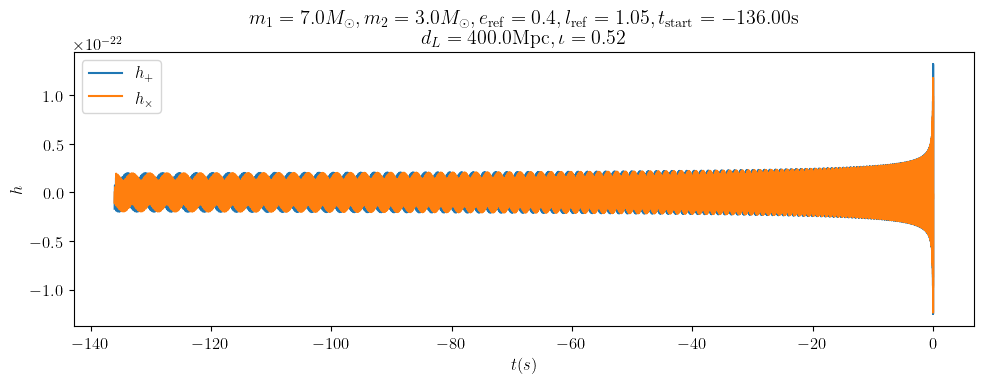

In [3]:
m1 = 7. # masses (in solar masses) 
m2 = 3.
reference_eccentricity = 0.4 # reference eccentricity
reference_mean_anomaly = 60 * np.pi/180. # reference mean anomaly

distance = 400. # source luminosity distance (in Mpc)
inclination = 30 * np.pi/180. # orbital inclination with line-of-sight

delta_t = 1/2**12 # time grid-spacing (in s)
t_start = -136. # Waveform starting time (in s). t=0 corresponds to the end of waveform, so the starting time should be a negative real number

hp, hc = esigmasur.get_inspiral_esigmasur_waveform(
    mass1=m1,
    mass2=m2,
    reference_eccentricity=reference_eccentricity,
    reference_mean_anomaly=reference_mean_anomaly,
    delta_t=delta_t, 
    t_start=t_start,
    distance=distance,
    inclination=inclination)

plt.figure(figsize=(10,4))
plt.title(fr"""$m_1={m1} M_\odot, m_2={m2} M_\odot, e_{{\rm{{ref}}}}={reference_eccentricity}, l_{{\rm{{ref}}}}={reference_mean_anomaly:.2f}, t_{{\rm{{start}}}}={t_start:.2f}\rm{{s}}$
          $d_L={distance}\rm{{Mpc}}, \iota={inclination:.2f}$""")
hp.plot(label=r"$h_+$")
hc.plot(label=r"$h_\times$")
plt.xlabel(r"$t (s)$")
plt.ylabel(r"$h$")
plt.legend()
plt.tight_layout()

The first surrogate evaluation will take more time for (a). loading the surrogate data, and (b). `numba` JIT compilation. 

### Waveform modes
One can also generate the spin-weighted spherical harmonic modes via the `get_inspiral_esigmasur_modes` function.

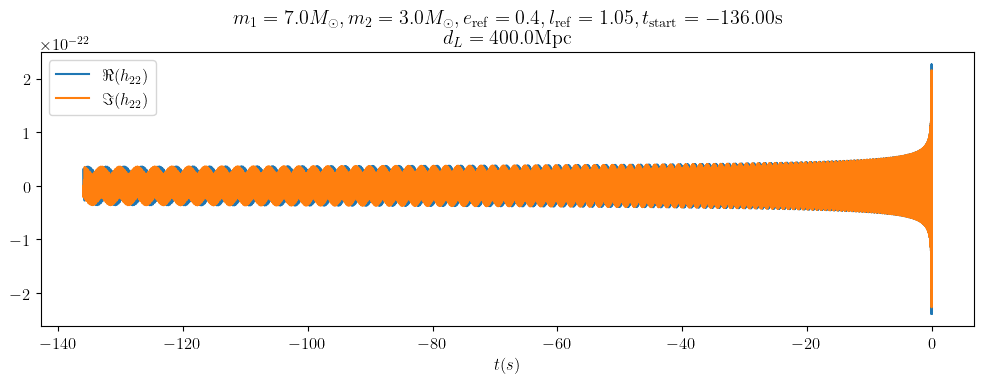

In [4]:
modes = esigmasur.get_inspiral_esigmasur_modes(
    mass1=m1,
    mass2=m2,
    reference_eccentricity=reference_eccentricity,
    reference_mean_anomaly=reference_mean_anomaly,
    delta_t=delta_t, 
    t_start=t_start,
    distance=distance)

plt.figure(figsize=(10, 4))
plt.title(fr"""$m_1={m1} M_\odot, m_2={m2} M_\odot, e_{{\rm{{ref}}}}={reference_eccentricity}, l_{{\rm{{ref}}}}={reference_mean_anomaly:.2f}, t_{{\rm{{start}}}}={t_start:.2f}\rm{{s}}$
          $d_L={distance}\rm{{Mpc}}$""")

mode_name = (2, 2)
ell, m = mode_name
plt.plot(modes[mode_name].sample_times.data, modes[mode_name].real().data, label=rf"$\Re(h_{{{ell} {m}}})$")
plt.plot(modes[mode_name].sample_times.data, modes[mode_name].imag().data, label=rf"$\Im(h_{{{ell} {m}}})$")
plt.legend(loc=2)
plt.xlabel(r"$t (s)$")
plt.ylabel(r"$h$")
plt.tight_layout()

## Evolution of orbital elements
The surrogates of binary's orbital elements' evolution can also be accessed via the argument `return_orbital_params` in all of the above discussed waveform/mode functions. The available orbital elements are

- $e$: Orbital eccentricity
- $l$: Mean anomaly
- $x$: The post-Newtonian (PN) parameter. It's related to the orbit-averaged (azimuthal) orbital frequency

$e$ and $l$ surrogates are internally required for surrogate waveform generation to get the values of eccentricity and mean anomaly at empirical interpolation (EI) nodes (i.e., $e_{\rm{EI}}$ and $l_{\rm{EI}}$) from their user-specified reference values (i.e., $e_{\rm{ref}}$ and $l_{\rm{ref}}$); see [arxiv:2510.00116](https://arxiv.org/abs/2510.00116) for details. 

$x$ surrogate is not required for inspiral surrogate waveform generation. It is only required by the merger-ringdown attachment algorithm (as detailed in [arxiv:2409.13866](https://arxiv.org/abs/2409.13866)) for producing an IMR waveform using the inspiral surrogate.

Text(0.5, 0, '$t (s)$')

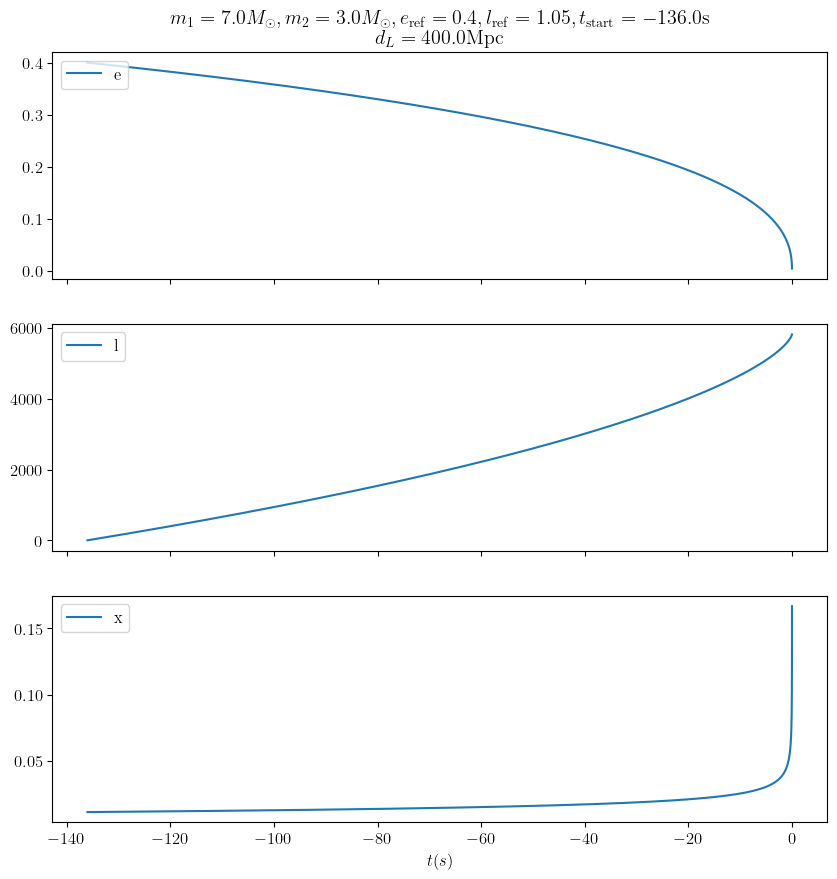

In [5]:
orb_params_list = ['e', 'l', 'x']

orb_vars, hp, hc = esigmasur.get_inspiral_esigmasur_waveform(
                                                    mass1=m1,
                                                    mass2=m2,
                                                    reference_eccentricity=reference_eccentricity,
                                                    reference_mean_anomaly=reference_mean_anomaly,
                                                    delta_t=delta_t, 
                                                    t_start=t_start,
                                                    distance=distance,
                                                    inclination=inclination,
                                                    return_orbital_params=orb_params_list)

fig, axs = plt.subplots(len(orb_params_list), sharex=True, figsize=(10, 10))
axs[0].set_title(fr"""$m_1={m1} M_\odot, m_2={m2} M_\odot, e_{{\rm{{ref}}}}={reference_eccentricity}, l_{{\rm{{ref}}}}={reference_mean_anomaly:.2f}, t_{{\rm{{start}}}}={t_start}\rm{{s}}$
          $d_L={distance}\rm{{Mpc}}$""")
for i, orb_params_name in enumerate(orb_params_list):
    axs[i].plot(orb_vars[orb_params_name].sample_times.data, orb_vars[orb_params_name].data, label=rf"{orb_params_name}")
    axs[i].legend(loc=2)
plt.xlabel(r"$t (s)$")

## Optional additions:

### IMR waveforms and modes
The inspiral surrogate can be used as a drop-in replacement for the inspiral piece in the `ESIGMA` framework, and can be smoothly attached to a quasi-circular plunge-merger-ringdown piece (`NRSur7dq4`, by default). Therefore, note that this is not an eccentric IMR surrogate, but rather a hybrid of an eccentric inspiral surrogate (`InspiralESIGMASur`) and a quasi-circular plunge-merger-ringdown surrogate (`NRSur7dq4`).

Running the following cell therefore will require installing the surrogate files for `NRSur7dq4`.

In [ ]:
hp, hc = esigmasur.get_imr_esigmasur_waveform(
    mass1=m1,
    mass2=m2,
    reference_eccentricity=reference_eccentricity,
    reference_mean_anomaly=reference_mean_anomaly,
    delta_t=delta_t, 
    t_start=t_start,
    distance=distance,
    inclination=inclination)

plt.figure(figsize=(10,4))
plt.title(fr"""$m_1={m1} M_\odot, m_2={m2} M_\odot, e_{{\rm{{ref}}}}={reference_eccentricity}, l_{{\rm{{ref}}}}={reference_mean_anomaly:.2f}, t_{{\rm{{start}}}}={t_start:.2f}\rm{{s}}$
          $d_L={distance}\rm{{Mpc}}, \iota={inclination:.2f}$""")
hp.plot(label=r"$h_+$")
hc.plot(label=r"$h_\times$")
plt.xlabel(r"$t (s)$")
plt.ylabel(r"$h$")
plt.legend()
plt.tight_layout()

In [ ]:
modes = esigmasur.get_imr_esigmasur_mode(
    mass1=m1,
    mass2=m2,
    reference_eccentricity=reference_eccentricity,
    reference_mean_anomaly=reference_mean_anomaly,
    delta_t=delta_t, 
    t_start=t_start,
    distance=distance,
    include_conjugate_modes=True,
    )

plt.figure(figsize=(10, 4))
plt.title(fr"""$m_1={m1} M_\odot, m_2={m2} M_\odot, e_{{\rm{{ref}}}}={reference_eccentricity}, l_{{\rm{{ref}}}}={reference_mean_anomaly:.2f}, t_{{\rm{{start}}}}={t_start}\rm{{s}}$
          $d_L={distance}\rm{{Mpc}}$""")

mode_name = (2, 2)
ell, m = mode_name
plt.plot(modes[mode_name].sample_times.data, modes[mode_name].real().data, label=rf"$\Re(h_{{{ell} {m}}})$")
plt.plot(modes[mode_name].sample_times.data, modes[mode_name].imag().data, label=rf"$\Im(h_{{{ell} {m}}})$")
plt.legend(loc=2)
plt.xlabel(r"$t (s)$")
plt.tight_layout()

### Evaluation over generic time-grids:
The inspiral surrogate can also be evaluated at a user-specified time-grid (sorted in ascending order), which can also be non-uniform, by supplying it to `times` option in the waveform/mode generation functions as a `NumPy` array. 

As an example, we use this feature to sample the waveform uniformly in GW phase instead of time. Consequently, in the plot below one can observe that
1. within any cycle, the time sampling is denser near the peaks and troughs, where the waveform changes rapidly
2. the time-sampling becomes denser near the end of inspiral, where the waveform evolves rapidly

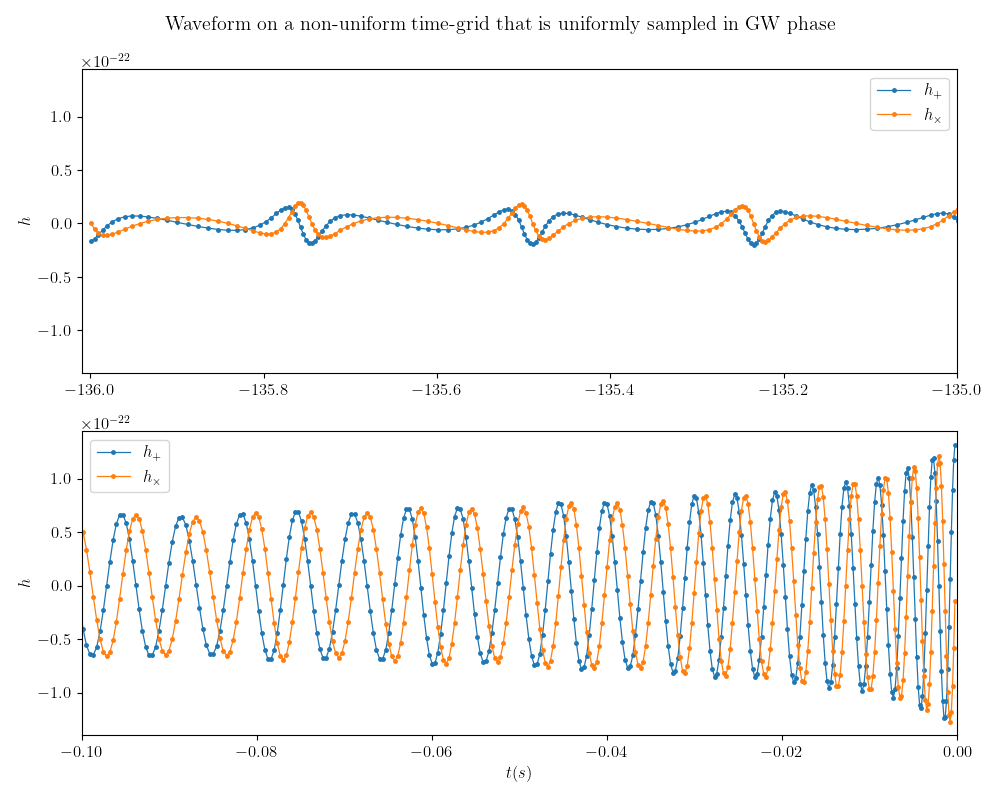

In [19]:
# Generating the same waveform as above
hp, hc = esigmasur.get_inspiral_esigmasur_waveform(
    mass1=m1,
    mass2=m2,
    reference_eccentricity=reference_eccentricity,
    reference_mean_anomaly=reference_mean_anomaly,
    delta_t = delta_t, 
    t_start=t_start,
    distance=distance,
    inclination=inclination)

# Computing a non-uniform time-grid that is uniformly sampled in GW phase instead
phase_gw = np.unwrap(np.arctan2(hc.data, hp.data))
num_points_per_cycle = 18
uniform_phase_grid = np.linspace(phase_gw[2], phase_gw[-2], int(num_points_per_cycle*(phase_gw[-2] - phase_gw[2])/(2*np.pi)), endpoint=True)
time_grid_uniformly_sampled_in_phase = np.interp(uniform_phase_grid, phase_gw, hp.sample_times.data)

# time_grid = -np.logspace(np.log10(0.001), np.log10(20), 5000)[::-1]

# Generating the waveform on the non-uniform time grid by passing it to the `times` argument
t, hp, hc = esigmasur.get_inspiral_esigmasur_waveform(
    mass1=m1,
    mass2=m2,
    reference_eccentricity=reference_eccentricity,
    reference_mean_anomaly=reference_mean_anomaly,
    times=time_grid_uniformly_sampled_in_phase, 
    distance=distance,
    inclination=inclination,
    return_pycbc_timeseries=False, # When giving a custom time-grid, can't return waveform as a PyCBC TimeSeries object
)

# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
fig.suptitle(r"Waveform on a non-uniform time-grid that is uniformly sampled in GW phase")

ax1.plot(t, hp, marker='.', lw=0.9, markersize=5, label=r"$h_+$")
ax1.plot(t, hc, marker='.', lw=0.9, markersize=5, label=r"$h_\times$")
ax1.set_ylabel("$h$")
ax1.set_xlim(-136.01, -135.)
ax1.legend()

ax2.plot(t, hp, marker='.', lw=0.9, markersize=5, label=r"$h_+$")
ax2.plot(t, hc, marker='.', lw=0.9, markersize=5, label=r"$h_\times$")
ax2.set_ylabel("$h$")
ax2.set_xlim(-0.1, 0.)
ax2.legend()

plt.xlabel(r"$t (s)$")
plt.tight_layout()

### Surrogate metrics

In [42]:
sur = esigmasur.get_surrogate_object() # Expose the base surrogate object
param_space = sur.get_metadata("training_param_space") # Surrogate's training parameter space: [q, e_ref, l_ref] 

print(f"The surrogate is trained over {len(param_space)} InspiralESIGMA waveforms.\n")

full_eccentric_data_piece_names = {"res_amp": "Residual amplitude",
                       "res_phase": "Residual phase",
                       "res_circ_phase": "Residual circular phase",
                       "e": "Eccentricity dynamics",
                       "shifted_mean_anomaly": "Shifted mean anomaly dynamics"}

full_circular_data_piece_names = {"amp": "Circular amplitude",
                                 "phase": "Circular phase"}
                                  
print(f"The surrogate uses the following number of basis functions:\n")
for key, value in full_eccentric_data_piece_names.items():
    print(f"{value}: {len(sur.eim_B[key])}")
    
for key, value in full_circular_data_piece_names.items():
    print(f"{value}: {len(sur.circ_sur.eim_B[key])}")

The surrogate is trained over 1404 InspiralESIGMA waveforms.

The surrogate uses the following number of basis functions:

Residual amplitude: 36
Residual phase: 21
Residual circular phase: 4
Eccentricity dynamics: 7
Shifted mean anomaly dynamics: 7
Circular amplitude: 4
Circular phase: 4


### Surrogate's domain of validity in starting GW frequency  

The minimum GW frequency till which the surrogate can generate waveforms for a 10.0M_Sun binary across its entire parameter space = 12.5Hz
Equivalently, the minimum total binary mass for which the surrogate can generate waveforms from 15.0Hz across its entire parameter space = 8.3M_Sun


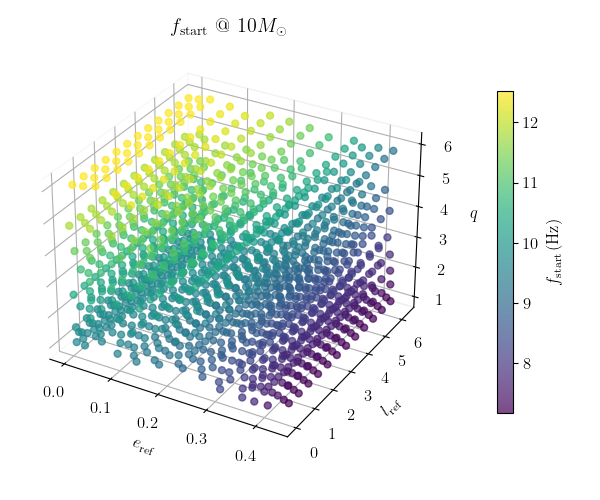

In [43]:
from esigmapy.utils import f22_from_x

M_eval = 10 # Total binary mass (in M_Sun) for which to compute the frequencies 
x_min_array = sur.get_metadata("x_min_array") # Contains the values of the PN parameter "x" at the starting of the surrogate's full length 
f_min_at_M_eval = f22_from_x(np.max(x_min_array), M=M_eval)
print(f"The minimum GW frequency till which the surrogate can generate waveforms for a {M_eval:.1f}M_Sun binary across its entire parameter space = {f_min_at_M_eval:.1f}Hz")

f_compute = 15. 
M_min_at_fcompute = M_eval * (f_min_at_M_eval/f_compute)
print(f"Equivalently, the minimum total binary mass for which the surrogate can generate waveforms from {f_compute}Hz across its entire parameter space = {M_min_at_fcompute:.1f}M_Sun")

plot_data = f22_from_x(x_min_array, M=M_eval) # Converting PN parameter to the orbit-averaged GW frequency

########### Plotting #############
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')

img = ax.scatter(
    param_space[:, 1], 
    param_space[:, 2], 
    param_space[:, 0], 
    c=plot_data,
    cmap='viridis', 
    s=25, 
    alpha=0.7,
)

cbar = fig.colorbar(img, ax=ax, shrink=0.7, pad=0.1)
cbar.set_label(r'$f_{\rm{start}} \, (\rm{Hz})$')

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

ax.set_title(fr"$f_{{\rm{{start}}}}$ @ ${M_eval:.0f} M_\odot$")
ax.set_zlabel(r'$q$')
ax.set_xlabel(r'$e_{\rm{ref}}$')
ax.set_ylabel(r'$l_{\rm{ref}}$')

plt.tight_layout()
plt.show()

### Surrogate's evaluation speed  

In [85]:
import time
from esigmapy.utils import x_from_f22
num_evals_per_mass = 25
f_low = 15.
delta_t = 1/2**12
total_mass_array = np.asarray([20, 30, 40, 50, 60, 80, 100, 120, 150.]) 

NLOOP = 10
def speeds(M, q, e_ref, l_ref, f_low, delta_t):
    m1 = q*M/(1 + q)
    m2 = M/(1 + q)
    t, orb_vars, modes = esigmasur.get_inspiral_esigmasur_modes(
                                                mass1=m1,
                                                mass2=m2,
                                                reference_eccentricity=e_ref,
                                                reference_mean_anomaly=l_ref,
                                                delta_t=delta_t, 
                                                t_start=None, # Generate the surrogate with its full duration
                                                return_pycbc_timeseries=False,
                                                return_orbital_params=["x"])
    x_start = x_from_f22(f_low, M=M)
    idx = np.argmax(orb_vars["x"] >= x_start)
    t_start = t[idx]

    t1 = time.perf_counter()
    t, modes = esigmasur.get_inspiral_esigmasur_modes(
                                                mass1=m1,
                                                mass2=m2,
                                                reference_eccentricity=e_ref,
                                                reference_mean_anomaly=l_ref,
                                                delta_t=delta_t, 
                                                t_start=t_start, # Generate the surrogate with its full duration
                                                return_pycbc_timeseries=False)
    sur_time = time.perf_counter() - t1
    
    if sur_time < 2.5e-2:
        temp_time = 0
        for _ in range(NLOOP-1):
            t1 = time.perf_counter()
            t, modes = esigmasur.get_inspiral_esigmasur_modes(
                                                mass1=m1,
                                                mass2=m2,
                                                reference_eccentricity=reference_eccentricity,
                                                reference_mean_anomaly=reference_mean_anomaly,
                                                delta_t=delta_t, 
                                                t_start=t_start, # Generate the surrogate with a duration such that
                                                                 # it starts from a GW frequency of f_low
                                                distance=distance,
                                                return_pycbc_timeseries=False)
            temp_time += time.perf_counter() - t1 
        sur_time += temp_time
        sur_time /= NLOOP
    return sur_time

total_mass_array = total_mass_array[total_mass_array > M_min_at_fcompute]
total_mass_array = np.r_[M_min_at_fcompute, total_mass_array]
sur_eval_times_dict = {}

for total_mass in total_mass_array: 
    rng = np.random.default_rng(seed=37)
    q_array = rng.uniform(1, 6, size=num_evals_per_mass)             
    e_array = rng.uniform(0, 0.43, size=num_evals_per_mass)        
    l_array = rng.uniform(0, 2 * np.pi, size=num_evals_per_mass)

    sur_eval_times = []
    for i in range(num_evals_per_mass):
        sur_eval_times.append(speeds(M=total_mass, 
                                   q=q_array[i], 
                                   e_ref=e_array[i], 
                                   l_ref=l_array[i], 
                                   f_low=f_low, 
                                   delta_t=delta_t))
    sur_eval_times_dict[total_mass] = sur_eval_times
    print(f"Time computation done for M = {total_mass:.2f} M_Sun")

Time computation done for M = 8.35 M_Sun
Time computation done for M = 20.00 M_Sun
Time computation done for M = 30.00 M_Sun
Time computation done for M = 40.00 M_Sun
Time computation done for M = 50.00 M_Sun
Time computation done for M = 60.00 M_Sun
Time computation done for M = 80.00 M_Sun
Time computation done for M = 100.00 M_Sun
Time computation done for M = 120.00 M_Sun
Time computation done for M = 150.00 M_Sun


Median evaluation time at M=8.346797309339665 M_sun = 27.505949001351837ms
Median evaluation time at M=20.0 M_sun = 11.074047499641893ms
Median evaluation time at M=30.0 M_sun = 9.05995070024801ms
Median evaluation time at M=40.0 M_sun = 8.582620000015595ms
Median evaluation time at M=50.0 M_sun = 8.220135799638228ms
Median evaluation time at M=60.0 M_sun = 7.976069799406105ms
Median evaluation time at M=80.0 M_sun = 8.04604240001936ms
Median evaluation time at M=100.0 M_sun = 8.240623300298466ms
Median evaluation time at M=120.0 M_sun = 9.42620679961692ms
Median evaluation time at M=150.0 M_sun = 9.418498599916347ms


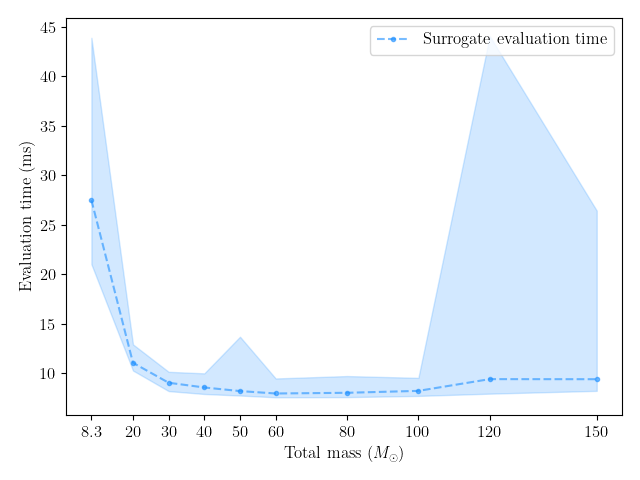

In [86]:
import matplotlib.ticker as mticker
fig, ax = plt.subplots()
ax.set_xlabel("Total mass ($M_\\odot$)")
ax.set_ylabel("Evaluation time (ms)")
# ax.set_yscale("log")

alpha_scatter = 0.6
alpha_fill = 0.2
color = "dodgerblue"

for mass, eval_times in sur_eval_times_dict.items():
    eval_times = np.asarray(eval_times)
    print(f"Median evaluation time at M={mass} M_sun = {np.median(eval_times*1.e3)}ms")

sur_eval_times_array = np.asarray(list(sur_eval_times_dict.values()))
sur_eval_times_median = np.median(sur_eval_times_array, axis=-1)
sur_speed_min = np.min(sur_eval_times_array, axis=-1)
sur_speed_max = np.max(sur_eval_times_array, axis=-1)

ax.plot(total_mass_array, sur_eval_times_median * 1.e3,
                ls="--", color=color, marker=".", alpha=alpha_scatter,
                label="Surrogate evaluation time")
ax.fill_between(total_mass_array,
                sur_speed_min * 1.e3,
                sur_speed_max * 1.e3,
                color=color, alpha=alpha_fill)


# Caution!!! Only the first tick will be shown with a decimal entry
def mixed_formatter(x, pos):
    # pos = index of tick in visible ticks
    if pos == 0:
        return f"{x:.1f}"   # first tick: 1 decimal place
    else:
        return f"{x:.0f}"   # others: no decimals
ax.xaxis.set_major_formatter(mticker.FuncFormatter(mixed_formatter))
plt.xticks(total_mass_array)

plt.legend()
plt.tight_layout()

In [82]:
sur_speed_median

array([0.02423446, 0.02473249, 0.02451255, 0.02751279, 0.02804672,
       0.02506734, 0.02563306, 0.02582466, 0.02583443, 0.02538609])

In [14]:
%%timeit

orb_vars, hp, hc = esigmasur.get_inspiral_esigmasur_waveform(
    mass1=10./7,
    mass2=6*10./7,
    reference_eccentricity=0.43,
    reference_mean_anomaly=1.,
    distance=400,
    delta_t = 1/2**12, 
    t_start=-136, 
    t_end=None,
    # include_conjugate_modes=True,
    return_pycbc_timeseries=True,
    return_orbital_params=["e", "l", "x"])


148 ms ± 8.24 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [101]:
%%timeit

t, orb_vars, hp, hc = esigmasur.get_inspiral_esigmasur_waveform(
    mass1=10./7,
    mass2=6*10./7,
    reference_eccentricity=0.43,
    reference_mean_anomaly=1.,
    distance=400,
    delta_t = 1/2**12, 
    t_start=-136, 
    t_end=None,
    # include_conjugate_modes=True,
    return_pycbc_timeseries=False,
    return_orbital_params=["e", "l", "x"])

68 ms ± 1.35 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [102]:
%%timeit

hp, hc = esigmasur.get_inspiral_esigmasur_waveform(
    mass1=10./7,
    mass2=6*10./7,
    reference_eccentricity=0.43,
    reference_mean_anomaly=1.,
    distance=400,
    delta_t = 1/2**12, 
    t_start=-136, 
    t_end=None,
    # include_conjugate_modes=True,
    return_pycbc_timeseries=True)


67.3 ms ± 619 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [103]:
%%timeit

t, hp, hc = esigmasur.get_inspiral_esigmasur_waveform(
    mass1=10./7,
    mass2=6*10./7,
    reference_eccentricity=0.43,
    reference_mean_anomaly=1.,
    distance=400,
    delta_t = 1/2**12, 
    t_start=-136, 
    t_end=None,
    # include_conjugate_modes=True,
    return_pycbc_timeseries=False)

60.2 ms ± 683 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [104]:
%%timeit

modes = esigmasur.get_inspiral_esigmasur_modes(
    mass1=10./7,
    mass2=6*10./7,
    reference_eccentricity=0.43,
    reference_mean_anomaly=1.,
    distance=400,
    delta_t = 1/2**12, 
    t_start=-136, 
    t_end=None,
    # include_conjugate_modes=True,
    return_pycbc_timeseries=True)

50.9 ms ± 753 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [17]:
%%timeit

t, modes = esigmasur.get_inspiral_esigmasur_modes(
    mass1=10./7,
    mass2=6*10./7,
    reference_eccentricity=0.43,
    reference_mean_anomaly=1.,
    distance=400,
    delta_t = 1/2**12, 
    t_start=-136, 
    t_end=None,
    # include_conjugate_modes=True,
    return_pycbc_timeseries=False)

54.6 ms ± 4.1 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [106]:
%%timeit

orb_vars, modes = esigmasur.get_imr_esigma_mode_sur(
    mass1=m1,
    mass2=m2,
    reference_eccentricity=reference_eccentricity,
    reference_mean_anomaly=reference_mean_anomaly,
    delta_t = 1/2**12, 
    t_start=t_start,
    distance=distance,
    return_orbital_params=orb_params_list
)


156 ms ± 3.29 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [16]:
%%timeit

modes = esigmasur.get_imr_esigmasur_mode(
    mass1=m1,
    mass2=m2,
    reference_eccentricity=reference_eccentricity,
    reference_mean_anomaly=reference_mean_anomaly,
    delta_t = 1/2**12, 
    t_start=t_start,
    distance=distance,
)

275 ms ± 10.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [113]:
import cProfile
import pstats

with cProfile.Profile() as pr:
    modes = esigmasur.get_imr_esigma_mode_sur(
        mass1=m1,
        mass2=m2,
        reference_eccentricity=reference_eccentricity,
        reference_mean_anomaly=reference_mean_anomaly,
        delta_t=1/2**12,
        t_start=t_start,
        distance=distance,
    )

stats = pstats.Stats(pr)
stats.sort_stats(pstats.SortKey.TIME)  # TIME sorts by tottime
stats.print_stats()  # top 20 functions

         3189 function calls (3102 primitive calls) in 0.155 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        5    0.023    0.005    0.023    0.005 /home/akash-x16/miniconda3/envs/esigma-igwn39/lib/python3.9/site-packages/numpy/lib/function_base.py:1602(angle)
  342/255    0.020    0.000    0.084    0.000 {built-in method numpy.core._multiarray_umath.implement_array_function}
        8    0.016    0.002    0.016    0.002 {built-in method numpy.core._multiarray_umath.interp}
        1    0.014    0.014    0.014    0.014 {built-in method lalsimulation._lalsimulation.SimInspiralChooseTDModes}
        5    0.013    0.003    0.022    0.004 /home/akash-x16/miniconda3/envs/esigma-igwn39/lib/python3.9/site-packages/numpy/lib/function_base.py:1659(unwrap)
        1    0.012    0.012    0.050    0.050 /home/akash-x16/miniconda3/envs/esigma-igwn39/lib/python3.9/site-packages/esigmapy/blend.py:187(blend_modes)
        1    0.008

In [8]:
modes = esigmasur.get_inspiral_esigmasur_modes(
    mass1=10./7,
    mass2=6*10./7,
    reference_eccentricity=0.43,
    reference_mean_anomaly=1.,
    distance=400,
    delta_t = 1/2**12, 
    t_start=-136, 
    t_end=None,
    include_conjugate_modes=True,
    return_pycbc_timeseries=True)

In [9]:
list(modes.keys())

[(2, 2), (2, -2)]